<h1>Learning with <b>selected</b> data</h1>

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

FEATURES = ["RR_l_0", "RR_l_0/RR_l_1", "RR_r_0", "R_val", "P_val", "signal_std"]

def print_classification_metrics(y_true, y_pred, average="macro"):

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average=average)
    rec = recall_score(y_true, y_pred, average=average)
    f1 = f1_score(y_true, y_pred, average=average)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    return acc, prec, rec, f1

# 1) Load your existing 80% learning data
learn_df = pd.read_csv("original_selected_features_data/learn_valid_80.csv")  # load CSV [web:79]

# 2) If you want a validation split from the 80%: e.g., 80/20 of the 80%
X_learn_selected = learn_df[FEATURES]
y_learn_selected = learn_df["label"]

X_train_selected, X_valid_selected, y_train_selected, y_valid_selected = train_test_split(
    X_learn_selected, y_learn_selected, test_size=0.20, random_state=42, shuffle=True, stratify=y_learn_selected
)  # stratified split preserves balance in train/valid [web:136]

# 3) Train KNN on the training portion
knn_selected_features = KNeighborsClassifier()
knn_selected_features.fit(X_train_selected, y_train_selected)

# 4) Validate
y_pred_val = knn_selected_features.predict(X_valid_selected)
print("Confusion matrix:\n", confusion_matrix(y_valid_selected, y_pred_val))
print_classification_metrics(y_valid_selected, y_pred_val)



Confusion matrix:
 [[158   2]
 [  8 152]]
Accuracy : 0.9688
Precision: 0.9694
Recall   : 0.9688
F1-score : 0.9687


(0.96875, 0.9694101079643248, 0.96875, 0.9687390098081357)

<h2>Holdout Strategija</h2>

In [55]:
test_df  = pd.read_csv("original_selected_features_data/test_20.csv")         # load test data  [web:79]

X_test_selected,  y_test_selected  = test_df[FEATURES],  test_df["label"]

# 3) Evaluate on the 20% test set
y_pred_test_selected = knn_selected_features.predict(X_test_selected)
print("Confusion matrix:\n", confusion_matrix(y_test_selected, y_pred_test_selected))
print_classification_metrics(y_test_selected, y_pred_test_selected)

Confusion matrix:
 [[197   3]
 [ 18 182]]
Accuracy : 0.9475
Precision: 0.9500
Recall   : 0.9475
F1-score : 0.9474


(0.9475, 0.9500314267756129, 0.9475, 0.9474260679079956)

<h2>Cross Validation strategija</h2>

In [56]:

scoring = {
    "acc": "accuracy",
    "prec": "precision_macro",
    "rec": "recall_macro",
    "f1": "f1_macro",
}

cv_results = cross_validate(knn_selected_features, X_learn_selected, y_learn_selected,
                            scoring=scoring)

print("Accuracy mean:", cv_results["test_acc"].mean())
print("Precision mean:", cv_results["test_prec"].mean())
print("Recall mean:", cv_results["test_rec"].mean())
print("F1 mean:", cv_results["test_f1"].mean())



Accuracy mean: 0.9581250000000001
Precision mean: 0.9600599296388316
Recall mean: 0.9581250000000001
F1 mean: 0.9580673901727497


Accuracy : 0.9475
Precision: 0.9500
Recall   : 0.9475
F1-score : 0.9474
Accuracy : 0.9688
Precision: 0.9694
Recall   : 0.9688
F1-score : 0.9687


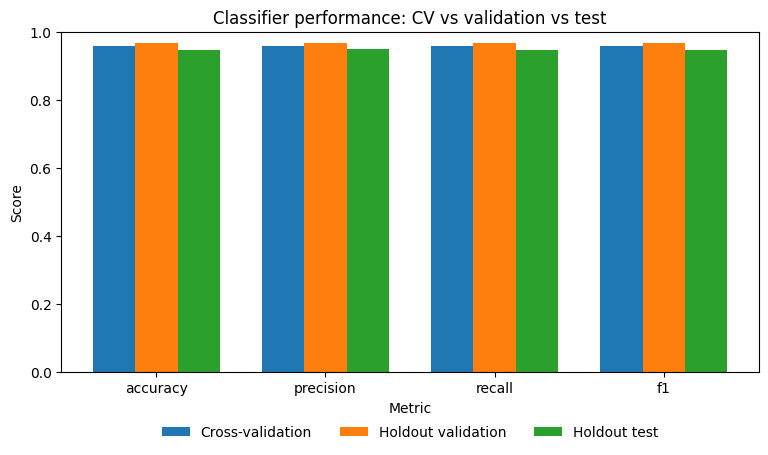

In [57]:
# Holdout (test) metrics
acc_test, prec_test, rec_test, f1_test = print_classification_metrics(y_test_selected, y_pred_test_selected)
acc_val, prec_val, rec_val, f1_val = print_classification_metrics(y_valid_selected, y_pred_val)
# Cross-validation (mean metrics)
acc_cv  = cv_results["test_acc"].mean()
prec_cv = cv_results["test_prec"].mean()
rec_cv  = cv_results["test_rec"].mean()
f1_cv   = cv_results["test_f1"].mean()

metrics = ["accuracy", "precision", "recall", "f1"]

cv_vals      = [acc_cv,   prec_cv,   rec_cv,   f1_cv]
val_vals     = [acc_val,  prec_val,  rec_val,  f1_val]
test_vals    = [acc_test, prec_test, rec_test, f1_test]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(9, 5))
plt.bar(x - width,        cv_vals,   width, label="Cross-validation")
plt.bar(x,                val_vals,  width, label="Holdout validation")
plt.bar(x + width,        test_vals, width, label="Holdout test")

plt.xticks(x, metrics)
plt.ylim(0, 1.0)
plt.xlabel("Metric")
plt.ylabel("Score")
plt.title("Classifier performance: CV vs validation vs test")
plt.subplots_adjust(bottom=0.2)
plt.legend(loc="upper center",
           bbox_to_anchor=(0.5, -0.12),
           ncol=3,
           frameon=False)
plt.show()

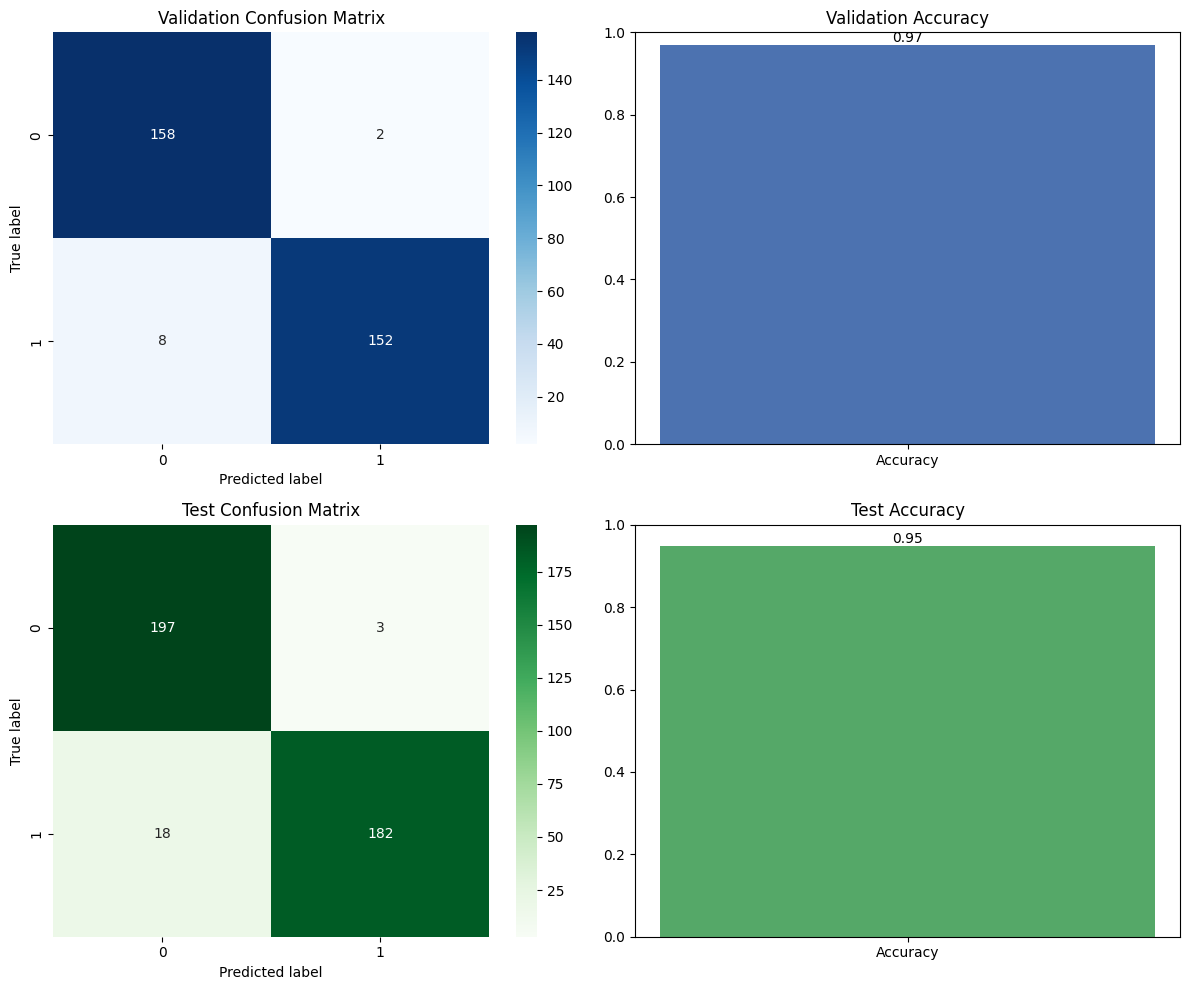

In [81]:
# 1) Validation predictions and metrics
y_valid_pred = knn_selected_features.predict(X_valid_selected)
valid_acc = accuracy_score(y_valid_selected, y_valid_pred)
valid_cm = confusion_matrix(y_valid_selected, y_valid_pred)
valid_report = classification_report(y_valid_selected, y_valid_pred, output_dict=True)

# 2) Test predictions and metrics
y_test_pred = knn_selected_features.predict(X_test_selected)
test_acc = accuracy_score(y_test_selected, y_test_pred)
test_cm = confusion_matrix(y_test_selected, y_test_pred)
test_report = classification_report(y_test_selected, y_test_pred, output_dict=True)

# Class labels in consistent order (rows/cols). If y is categorical text, get unique labels from combined sets.
# Using sklearn's labels derived from confusion_matrix inputs preserves order of unique labels encountered.
labels = sorted(list(set(pd.concat([pd.Series(y_valid_selected), pd.Series(y_test_selected)]).unique())))

# Recompute confusion matrices explicitly with a fixed label order for consistent axes
valid_cm = confusion_matrix(y_valid_selected, y_valid_pred, labels=labels)
test_cm  = confusion_matrix(y_test_selected,  y_test_pred,  labels=labels)

# 3) Plot confusion matrices (validation and test) side-by-side
fig, axes = plt.subplots(2, 2, figsize=(12, 10), gridspec_kw={'height_ratios': [4, 4]})

# Validation confusion matrix heatmap
sns.heatmap(pd.DataFrame(valid_cm, index=labels, columns=labels),
            annot=True, fmt="d", cmap="Blues", cbar=True, ax=axes[0,0])
axes[0,0].set_title("Validation Confusion Matrix")
axes[0,0].set_xlabel("Predicted label")
axes[0,0].set_ylabel("True label")

# Validation accuracy bar
axes[0,1].bar(["Accuracy"], [valid_acc], color="#4C72B0")
axes[0,1].set_ylim(0, 1)
axes[0,1].bar_label(axes[0,1].containers[0], fmt="%.2f")
axes[0,1].set_title("Validation Accuracy")

# Test confusion matrix heatmap
sns.heatmap(pd.DataFrame(test_cm, index=labels, columns=labels),
            annot=True, fmt="d", cmap="Greens", cbar=True, ax=axes[1,0])
axes[1,0].set_title("Test Confusion Matrix")
axes[1,0].set_xlabel("Predicted label")
axes[1,0].set_ylabel("True label")

# Test accuracy bar
axes[1,1].bar(["Accuracy"], [test_acc], color="#55A868")
axes[1,1].set_ylim(0, 1)
axes[1,1].bar_label(axes[1,1].containers[0], fmt="%.2f")
axes[1,1].set_title("Test Accuracy")

plt.tight_layout()
plt.show()

# 4) Per-class precision/recall/F1 bar chart for validation
valid_df = (
    pd.DataFrame(valid_report)
      .T
      .reset_index()
      .rename(columns={"index": "label"})
)


<h1>Learning with <b>tsne</b> data</h1>

In [60]:
# 1) Load your existing 80% learning data
learn_df = pd.read_csv("tsne_data/learn_valid_80.csv")  # load CSV [web:79]

# 2) If you want a validation split from the 80%: e.g., 80/20 of the 80%
X_learn_tsne = learn_df[["tsne_x", "tsne_y"]]
y_learn_tsne = learn_df["label"]

X_train_tsne, X_valid_tsne, y_train_tsne, y_valid_tsne = train_test_split(
    X_learn_tsne, y_learn_tsne, test_size=0.20, random_state=42, shuffle=True, stratify=y_learn_tsne
)  # stratified split preserves balance in train/valid [web:136]

# 3) Train KNN on the training portion
knn_tsne = KNeighborsClassifier()
knn_tsne.fit(X_train_tsne, y_train_tsne)

# 4) Validate
y_pred_val_tsne = knn_tsne.predict(X_valid_tsne)
print("Confusion matrix:\n", confusion_matrix(y_valid_tsne, y_pred_val_tsne))
print_classification_metrics(y_valid_tsne, y_pred_val_tsne)

Confusion matrix:
 [[157   3]
 [  9 151]]
Accuracy : 0.9625
Precision: 0.9632
Recall   : 0.9625
F1-score : 0.9625


(0.9625, 0.9631513065248005, 0.9624999999999999, 0.9624868117697628)

In [61]:
test_df  = pd.read_csv("tsne_data/test_20.csv")

X_test_tsne,  y_test_tsne  = test_df[["tsne_x", "tsne_y"]],  test_df["label"]

# 3) Evaluate on the 20% test set
y_pred_test_tsne = knn_tsne.predict(X_test_tsne)
print("Confusion matrix:\n", confusion_matrix(y_test_tsne, y_pred_test_tsne))
print_classification_metrics(y_test_tsne, y_pred_test_tsne)


Confusion matrix:
 [[196   4]
 [ 17 183]]
Accuracy : 0.9475
Precision: 0.9494
Recall   : 0.9475
F1-score : 0.9474


(0.9475, 0.9493987095478396, 0.9475, 0.9474444882407043)

c:\Users\Edas\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


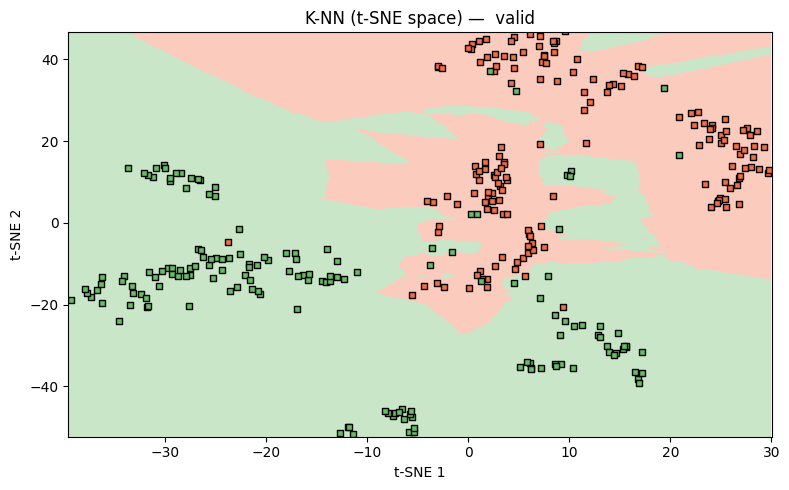

In [62]:
# 1) Prepare full extent (clip to reduce artifacts)
X_all = pd.concat([X_train_tsne, X_valid_tsne], axis=0)
pad = 1.0
x_min = X_all["tsne_x"].quantile(0.01) - pad
x_max = X_all["tsne_x"].quantile(0.99) + pad
y_min = X_all["tsne_y"].quantile(0.01) - pad
y_max = X_all["tsne_y"].quantile(0.99) + pad

# 2) Coarse grid for solid regions (fast + visually clean)
h = 0.25  # try 0.2–0.5; smaller = more detail, slower
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = knn_tsne.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# 3) Simple two-color background and all points on top
# Choose two solid background colors
from matplotlib.colors import ListedColormap
bg_cmap = ListedColormap(["#f46d43", "#66bd63"])  # orange/red vs green

plt.figure(figsize=(8, 5))
plt.pcolormesh(xx, yy, Z, cmap=bg_cmap, shading="nearest", alpha=0.35)

# Plot all points: train as circles, valid as squares; same color per class
# Map class -> color so it matches background classes
classes = np.unique(pd.concat([y_train_tsne, y_valid_tsne]))
point_colors = {c: bg_cmap.colors[i % len(bg_cmap.colors)] for i, c in enumerate(classes)}

# Valid
for cls in classes:
    m = y_valid_tsne == cls
    plt.scatter(X_valid_tsne.loc[m, "tsne_x"], X_valid_tsne.loc[m, "tsne_y"],
                c=point_colors[cls], edgecolors="k", s=25, marker="s")

# Labels and aspect
plt.xlim(x_min, x_max); plt.ylim(y_min, y_max)
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.title("K-NN (t-SNE space) —  valid")
plt.tight_layout()
plt.show()


c:\Users\Edas\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


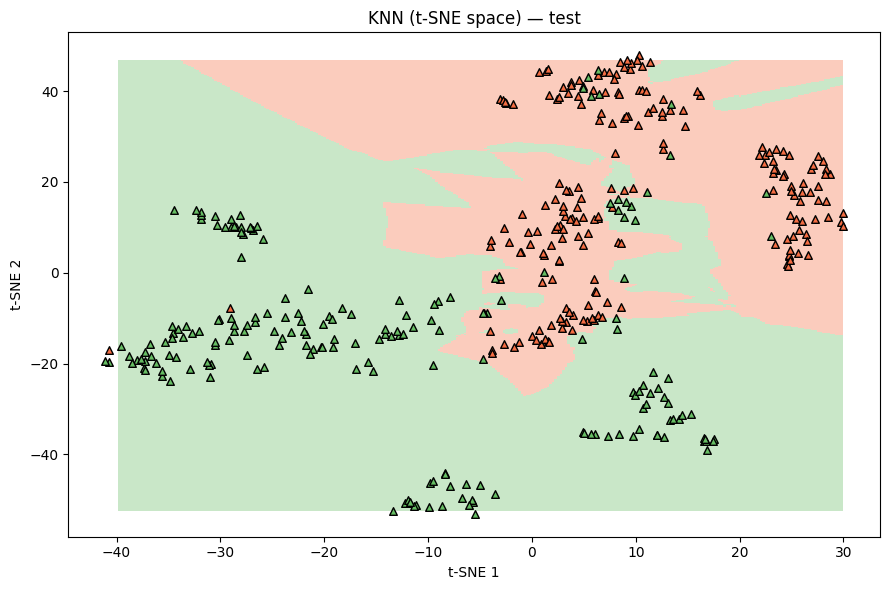

In [64]:

# 1) Rebuild or reuse the same grid over the combined extent (train+valid+test)
X_all = pd.concat([X_train_tsne, X_valid_tsne, X_test_tsne], axis=0)

pad, h = 1.0, 0.25
x_min = X_all["tsne_x"].quantile(0.01) - pad
x_max = X_all["tsne_x"].quantile(0.99) + pad
y_min = X_all["tsne_y"].quantile(0.01) - pad
y_max = X_all["tsne_y"].quantile(0.99) + pad
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = knn_tsne.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# 2) Consistent two-color background
bg_cmap = ListedColormap(["#f46d43", "#66bd63"])  # orange vs green
plt.figure(figsize=(9, 6))
plt.pcolormesh(xx, yy, Z, cmap=bg_cmap, shading="nearest", alpha=0.35)

# 3) Color mapping for points to match classes
classes = np.unique(pd.concat([y_train_tsne, y_valid_tsne, y_test_tsne]))
point_colors = {c: bg_cmap.colors[i % len(bg_cmap.colors)] for i, c in enumerate(classes)}

for cls in classes:
    m = y_test_tsne == cls
    plt.scatter(X_test_tsne.loc[m, "tsne_x"], X_test_tsne.loc[m, "tsne_y"],
                c=point_colors[cls], edgecolors="k", s=30, marker="^")  # test as triangles

plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2")
plt.title("KNN (t-SNE space) — test")
plt.tight_layout(); plt.show()


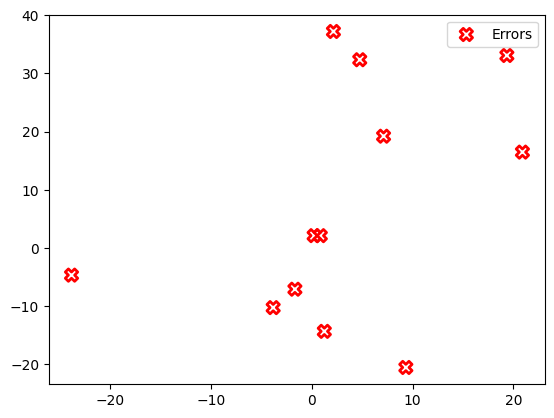

In [65]:
# Prognozės ir tikimybės (jei yra)
y_pred = knn_tsne.predict(X_valid_tsne[["tsne_x", "tsne_y"]])
proba = knn_tsne.predict_proba(X_valid_tsne[["tsne_x", "tsne_y"]])

df_val = X_valid_tsne.copy()
df_val["y_true"] = y_valid_tsne.values
df_val["y_pred"] = y_pred
df_val["correct"] = df_val["y_true"] == df_val["y_pred"]
df_val["conf"] = proba.max(axis=1)

worst = df_val[~df_val["correct"]]
# Po esamo ciklo, kuris piešia valid taškus:
plt.scatter(worst["tsne_x"], worst["tsne_y"],
            facecolors="none", edgecolors="red",
            s=80, marker="X", linewidths=2, label="Errors")

plt.legend()
plt.show()


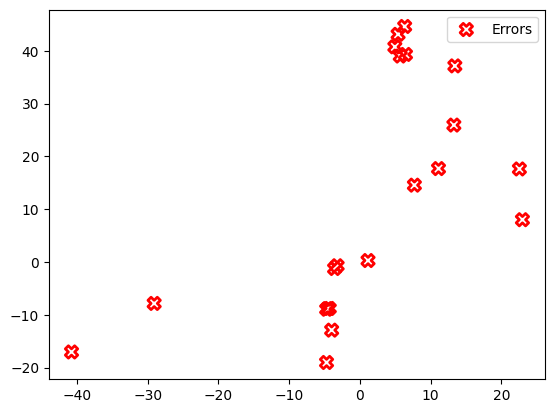

In [66]:
# Prognozės ir tikimybės (jei yra)
y_pred = knn_tsne.predict(X_test_tsne[["tsne_x", "tsne_y"]])
proba = knn_tsne.predict_proba(X_test_tsne[["tsne_x", "tsne_y"]])

df_val = X_test_tsne.copy()
df_val["y_true"] = y_test_tsne.values
df_val["y_pred"] = y_pred
df_val["correct"] = df_val["y_true"] == df_val["y_pred"]
df_val["conf"] = proba.max(axis=1)

worst = df_val[~df_val["correct"]]
# Po esamo ciklo, kuris piešia valid taškus:
plt.scatter(worst["tsne_x"], worst["tsne_y"],
            facecolors="none", edgecolors="red",
            s=80, marker="X", linewidths=2, label="Errors")

plt.legend()
plt.show()


In [67]:

scoring = {
    "acc": "accuracy",
    "prec": "precision_macro",
    "rec": "recall_macro",
    "f1": "f1_macro",
}

cv_results = cross_validate(knn_selected_features, X_learn_tsne, y_learn_tsne,
                            scoring=scoring)

print("Accuracy mean:", cv_results["test_acc"].mean())
print("Precision mean:", cv_results["test_prec"].mean())
print("Recall mean:", cv_results["test_rec"].mean())
print("F1 mean:", cv_results["test_f1"].mean())



Accuracy mean: 0.954375
Precision mean: 0.9556745412007803
Recall mean: 0.954375
F1 mean: 0.9543359061297052


Accuracy : 0.9475
Precision: 0.9494
Recall   : 0.9475
F1-score : 0.9474
Accuracy : 0.9688
Precision: 0.9694
Recall   : 0.9688
F1-score : 0.9687


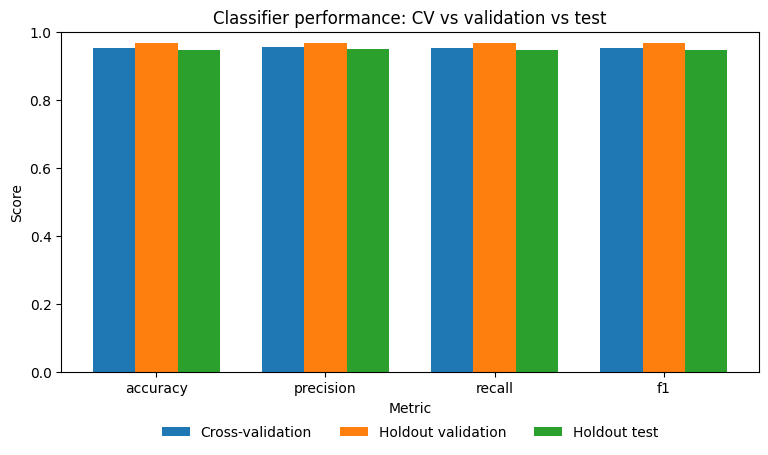

In [68]:
# Holdout (test) metrics
acc_test, prec_test, rec_test, f1_test = print_classification_metrics(y_test_tsne, y_pred_test_tsne)
acc_val, prec_val, rec_val, f1_val = print_classification_metrics(y_valid_tsne, y_pred_val)
# Cross-validation (mean metrics)
acc_cv  = cv_results["test_acc"].mean()
prec_cv = cv_results["test_prec"].mean()
rec_cv  = cv_results["test_rec"].mean()
f1_cv   = cv_results["test_f1"].mean()

metrics = ["accuracy", "precision", "recall", "f1"]

cv_vals      = [acc_cv,   prec_cv,   rec_cv,   f1_cv]
val_vals     = [acc_val,  prec_val,  rec_val,  f1_val]
test_vals    = [acc_test, prec_test, rec_test, f1_test]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(9, 5))
plt.bar(x - width,        cv_vals,   width, label="Cross-validation")
plt.bar(x,                val_vals,  width, label="Holdout validation")
plt.bar(x + width,        test_vals, width, label="Holdout test")

plt.xticks(x, metrics)
plt.ylim(0, 1.0)
plt.xlabel("Metric")
plt.ylabel("Score")
plt.title("Classifier performance: CV vs validation vs test")
plt.subplots_adjust(bottom=0.2)
plt.legend(loc="upper center",
           bbox_to_anchor=(0.5, -0.12),
           ncol=3,
           frameon=False)
plt.show()

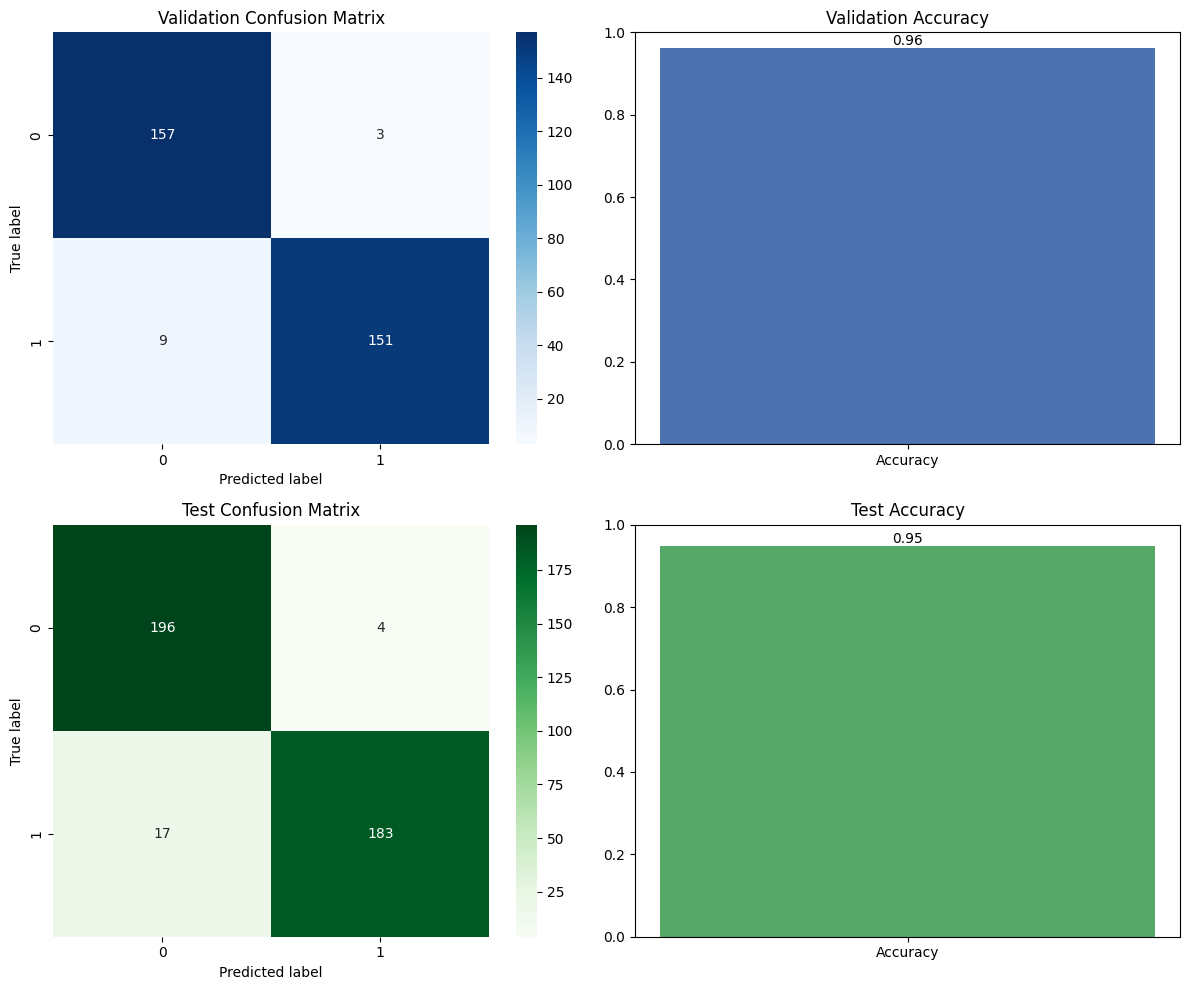

In [82]:
# 1) Validation predictions and metrics
y_valid_pred = knn_tsne.predict(X_valid_tsne)
valid_acc = accuracy_score(y_valid_tsne, y_valid_pred)
valid_cm = confusion_matrix(y_valid_tsne, y_valid_pred)
valid_report = classification_report(y_valid_tsne, y_valid_pred, output_dict=True)

# 2) Test predictions and metrics
y_test_pred = knn_tsne.predict(X_test_tsne)
test_acc = accuracy_score(y_test_tsne, y_test_pred)
test_cm = confusion_matrix(y_test_tsne, y_test_pred)
test_report = classification_report(y_test_tsne, y_test_pred, output_dict=True)

# Class labels in consistent order (rows/cols). If y is categorical text, get unique labels from combined sets.
# Using sklearn's labels derived from confusion_matrix inputs preserves order of unique labels encountered.
labels = sorted(list(set(pd.concat([pd.Series(y_valid_tsne), pd.Series(y_test_tsne)]).unique())))

# Recompute confusion matrices explicitly with a fixed label order for consistent axes
valid_cm = confusion_matrix(y_valid_tsne, y_valid_pred, labels=labels)
test_cm  = confusion_matrix(y_test_tsne,  y_test_pred,  labels=labels)

# 3) Plot confusion matrices (validation and test) side-by-side
fig, axes = plt.subplots(2, 2, figsize=(12, 10), gridspec_kw={'height_ratios': [4, 4]})

# Validation confusion matrix heatmap
sns.heatmap(pd.DataFrame(valid_cm, index=labels, columns=labels),
            annot=True, fmt="d", cmap="Blues", cbar=True, ax=axes[0,0])
axes[0,0].set_title("Validation Confusion Matrix")
axes[0,0].set_xlabel("Predicted label")
axes[0,0].set_ylabel("True label")

# Validation accuracy bar
axes[0,1].bar(["Accuracy"], [valid_acc], color="#4C72B0")
axes[0,1].set_ylim(0, 1)
axes[0,1].bar_label(axes[0,1].containers[0], fmt="%.2f")
axes[0,1].set_title("Validation Accuracy")

# Test confusion matrix heatmap
sns.heatmap(pd.DataFrame(test_cm, index=labels, columns=labels),
            annot=True, fmt="d", cmap="Greens", cbar=True, ax=axes[1,0])
axes[1,0].set_title("Test Confusion Matrix")
axes[1,0].set_xlabel("Predicted label")
axes[1,0].set_ylabel("True label")

# Test accuracy bar
axes[1,1].bar(["Accuracy"], [test_acc], color="#55A868")
axes[1,1].set_ylim(0, 1)
axes[1,1].bar_label(axes[1,1].containers[0], fmt="%.2f")
axes[1,1].set_title("Test Accuracy")

plt.tight_layout()
plt.show()

# 4) Per-class precision/recall/F1 bar chart for validation
valid_df = (
    pd.DataFrame(valid_report)
      .T
      .reset_index()
      .rename(columns={"index": "label"})
)


<h1>Learning with <b>all</b> data</h1>

In [69]:
learn_df = pd.read_csv("original_all_features_data/learn_valid_80.csv")  # load CSV [web:79]

# keep only numeric columns
numeric_cols = learn_df.select_dtypes(include=[np.number]).columns

# features = all numeric columns except label (in case label is numeric)
feature_cols = numeric_cols.drop("label") if "label" in numeric_cols else numeric_cols

X_learn_all = learn_df[feature_cols]
y_learn_all = learn_df["label"]

X_train_all, X_valid_all, y_train_all, y_valid_all = train_test_split(
    X_learn_all, y_learn_all, test_size=0.20, random_state=42, shuffle=True, stratify=y_learn_all
)


# 3) Train KNN on the training portion
knn_all_features = KNeighborsClassifier(n_neighbors=5, weights="distance", metric="euclidean")
knn_all_features.fit(X_train_all, y_train_all)

# 4) Validate
y_pred_val_all = knn_all_features.predict(X_valid_all)
print("Confusion matrix:\n", confusion_matrix(y_valid_all, y_pred_val_all))
print_classification_metrics(y_valid_all, y_pred_val_all)

Confusion matrix:
 [[160   0]
 [  4 156]]
Accuracy : 0.9875
Precision: 0.9878
Recall   : 0.9875
F1-score : 0.9875


(0.9875, 0.9878048780487805, 0.9875, 0.9874980465697765)

In [70]:
test_df  = pd.read_csv("original_all_features_data/test_20.csv")

X_test_all,  y_test_all  = test_df[feature_cols],  test_df["label"]

# 3) Evaluate on the 20% test set
y_pred_test = knn_all_features.predict(X_test_all)
print("Confusion matrix:\n", confusion_matrix(y_test_all, y_pred_test))
print_classification_metrics(y_test_all, y_pred_test)


Confusion matrix:
 [[200   0]
 [  5 195]]
Accuracy : 0.9875
Precision: 0.9878
Recall   : 0.9875
F1-score : 0.9875


(0.9875, 0.9878048780487805, 0.9875, 0.9874980465697765)

In [71]:
scoring = {
    "acc": "accuracy",
    "prec": "precision_macro",
    "rec": "recall_macro",
    "f1": "f1_macro",
}

cv_results = cross_validate(knn_all_features, X_learn_all, y_learn_all,
                            scoring=scoring)

print("Accuracy mean:", cv_results["test_acc"].mean())
print("Precision mean:", cv_results["test_prec"].mean())
print("Recall mean:", cv_results["test_rec"].mean())
print("F1 mean:", cv_results["test_f1"].mean())



Accuracy mean: 0.9875
Precision mean: 0.9879562246567367
Recall mean: 0.9875
F1 mean: 0.9874946747738992


Accuracy : 0.9875
Precision: 0.9878
Recall   : 0.9875
F1-score : 0.9875
Accuracy : 0.9688
Precision: 0.9694
Recall   : 0.9688
F1-score : 0.9687


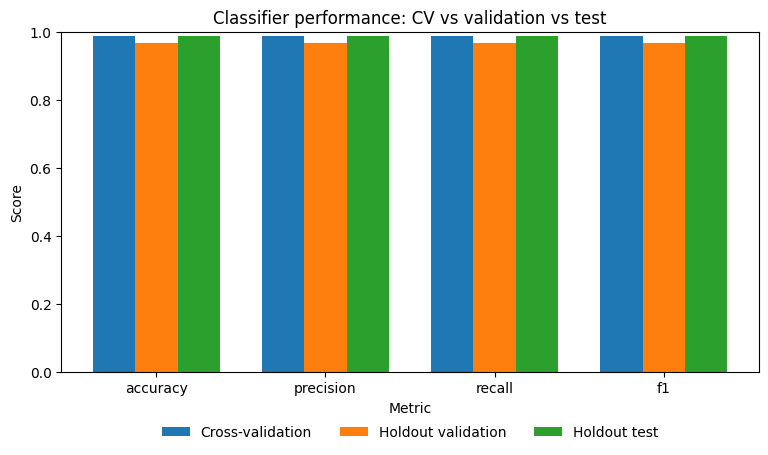

In [72]:
# Holdout (test) metrics
acc_test, prec_test, rec_test, f1_test = print_classification_metrics(y_test_all, y_pred_test)
acc_val, prec_val, rec_val, f1_val = print_classification_metrics(y_valid_all, y_pred_val)
# Cross-validation (mean metrics)
acc_cv  = cv_results["test_acc"].mean()
prec_cv = cv_results["test_prec"].mean()
rec_cv  = cv_results["test_rec"].mean()
f1_cv   = cv_results["test_f1"].mean()

metrics = ["accuracy", "precision", "recall", "f1"]

cv_vals      = [acc_cv,   prec_cv,   rec_cv,   f1_cv]
val_vals     = [acc_val,  prec_val,  rec_val,  f1_val]
test_vals    = [acc_test, prec_test, rec_test, f1_test]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(9, 5))
plt.bar(x - width,        cv_vals,   width, label="Cross-validation")
plt.bar(x,                val_vals,  width, label="Holdout validation")
plt.bar(x + width,        test_vals, width, label="Holdout test")

plt.xticks(x, metrics)
plt.ylim(0, 1.0)
plt.xlabel("Metric")
plt.ylabel("Score")
plt.title("Classifier performance: CV vs validation vs test")
plt.subplots_adjust(bottom=0.2)
plt.legend(loc="upper center",
           bbox_to_anchor=(0.5, -0.12),
           ncol=3,
           frameon=False)
plt.show()

<h1>Optimizing <b>all</b> data set</h1>

In [74]:
ks = [5, 15, 25]
metrics = ["euclidean", "manhattan", "cosine"]  # minkowski removed; uniform weights by default

for k in ks:
    for metric in metrics:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)  # uniform weights (default)
        knn.fit(X_train_all, y_train_all)

        y_pred = knn.predict(X_valid_all)
        acc = accuracy_score(y_valid_all, y_pred)
        print(f"\nKNN k={k}, metric={metric}  ->  Val accuracy: {acc:.4f}")
        print("Confusion matrix:\n", confusion_matrix(y_valid_all, y_pred))
        print_classification_metrics(y_valid_all, y_pred)


KNN k=5, metric=euclidean  ->  Val accuracy: 0.9875
Confusion matrix:
 [[160   0]
 [  4 156]]
Accuracy : 0.9875
Precision: 0.9878
Recall   : 0.9875
F1-score : 0.9875

KNN k=5, metric=manhattan  ->  Val accuracy: 0.9906
Confusion matrix:
 [[160   0]
 [  3 157]]
Accuracy : 0.9906
Precision: 0.9908
Recall   : 0.9906
F1-score : 0.9906

KNN k=5, metric=cosine  ->  Val accuracy: 0.9906
Confusion matrix:
 [[160   0]
 [  3 157]]
Accuracy : 0.9906
Precision: 0.9908
Recall   : 0.9906
F1-score : 0.9906

KNN k=15, metric=euclidean  ->  Val accuracy: 0.9875
Confusion matrix:
 [[160   0]
 [  4 156]]
Accuracy : 0.9875
Precision: 0.9878
Recall   : 0.9875
F1-score : 0.9875

KNN k=15, metric=manhattan  ->  Val accuracy: 0.9875
Confusion matrix:
 [[160   0]
 [  4 156]]
Accuracy : 0.9875
Precision: 0.9878
Recall   : 0.9875
F1-score : 0.9875

KNN k=15, metric=cosine  ->  Val accuracy: 0.9875
Confusion matrix:
 [[160   0]
 [  4 156]]
Accuracy : 0.9875
Precision: 0.9878
Recall   : 0.9875
F1-score : 0.9875



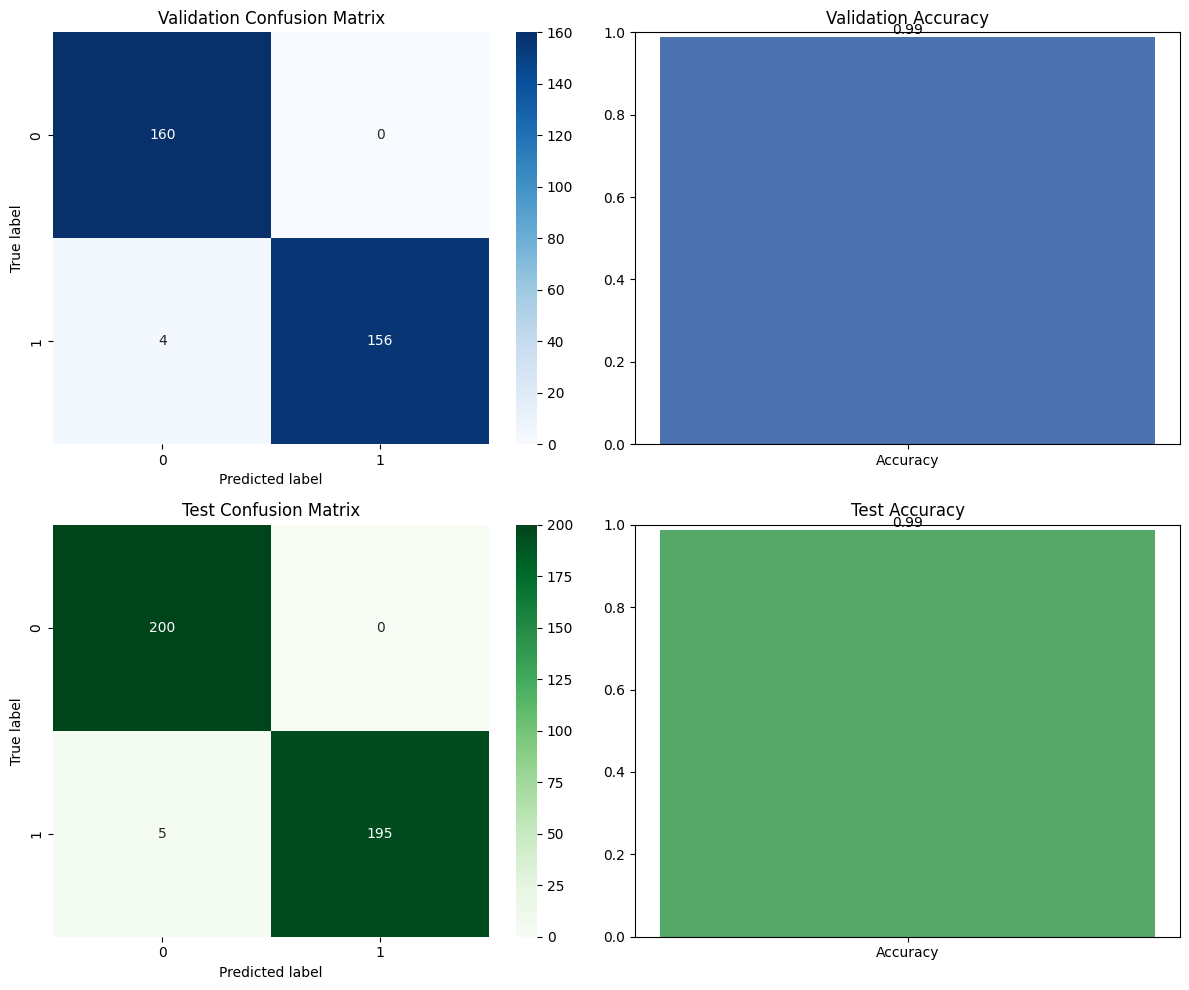

In [ ]:
# 1) Validation predictions and metrics
y_valid_pred = knn_all_features.predict(X_valid_all)
valid_acc = accuracy_score(y_valid_all, y_valid_pred)
valid_cm = confusion_matrix(y_valid_all, y_valid_pred)
valid_report = classification_report(y_valid_all, y_valid_pred, output_dict=True)

# 2) Test predictions and metrics
y_test_pred = knn_all_features.predict(X_test_all)
test_acc = accuracy_score(y_test_all, y_test_pred)
test_cm = confusion_matrix(y_test_all, y_test_pred)
test_report = classification_report(y_test_all, y_test_pred, output_dict=True)

# Class labels in consistent order (rows/cols). If y is categorical text, get unique labels from combined sets.
# Using sklearn's labels derived from confusion_matrix inputs preserves order of unique labels encountered.
labels = sorted(list(set(pd.concat([pd.Series(y_valid_all), pd.Series(y_test_all)]).unique())))

# Recompute confusion matrices explicitly with a fixed label order for consistent axes
valid_cm = confusion_matrix(y_valid_all, y_valid_pred, labels=labels)
test_cm  = confusion_matrix(y_test_all,  y_test_pred,  labels=labels)

# 3) Plot confusion matrices (validation and test) side-by-side
fig, axes = plt.subplots(2, 2, figsize=(12, 10), gridspec_kw={'height_ratios': [4, 4]})

# Validation confusion matrix heatmap
sns.heatmap(pd.DataFrame(valid_cm, index=labels, columns=labels),
            annot=True, fmt="d", cmap="Blues", cbar=True, ax=axes[0,0])
axes[0,0].set_title("Validation Confusion Matrix")
axes[0,0].set_xlabel("Predicted label")
axes[0,0].set_ylabel("True label")

# Validation accuracy bar
axes[0,1].bar(["Accuracy"], [valid_acc], color="#4C72B0")
axes[0,1].set_ylim(0, 1)
axes[0,1].bar_label(axes[0,1].containers[0], fmt="%.2f")
axes[0,1].set_title("Validation Accuracy")

# Test confusion matrix heatmap
sns.heatmap(pd.DataFrame(test_cm, index=labels, columns=labels),
            annot=True, fmt="d", cmap="Greens", cbar=True, ax=axes[1,0])
axes[1,0].set_title("Test Confusion Matrix")
axes[1,0].set_xlabel("Predicted label")
axes[1,0].set_ylabel("True label")

# Test accuracy bar
axes[1,1].bar(["Accuracy"], [test_acc], color="#55A868")
axes[1,1].set_ylim(0, 1)
axes[1,1].bar_label(axes[1,1].containers[0], fmt="%.2f")
axes[1,1].set_title("Test Accuracy")

plt.tight_layout()
plt.show()

# 4) Per-class precision/recall/F1 bar chart for validation
valid_df = (
    pd.DataFrame(valid_report)
      .T
      .reset_index()
      .rename(columns={"index": "label"})
)


In [76]:
knn = KNeighborsClassifier(n_neighbors=5, metric="manhattan")  # uniform weights (default)

scoring = {
    "acc": "accuracy",
    "prec": "precision_macro",
    "rec": "recall_macro",
    "f1": "f1_macro",
}

cv_results = cross_validate(knn, X_learn_all, y_learn_all,
                            scoring=scoring)

print("Accuracy mean:", cv_results["test_acc"].mean())
print("Precision mean:", cv_results["test_prec"].mean())
print("Recall mean:", cv_results["test_rec"].mean())
print("F1 mean:", cv_results["test_f1"].mean())


Accuracy mean: 0.9875
Precision mean: 0.9879970902136289
Recall mean: 0.9875
F1 mean: 0.987493023628681


<h1>Analytics</h1>

AUC (all features)     : 0.9938
AUC (selected features): 0.9843
AUC (t-SNE space)      : 0.9742


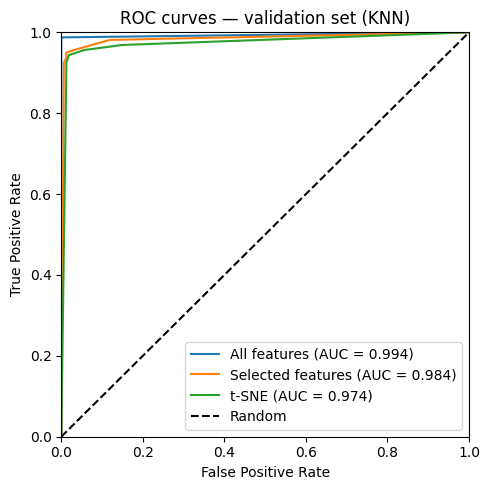

In [80]:

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
)
y_score_val_all      = knn_all_features.predict_proba(X_valid_all)[:, 1]
y_score_val_selected = knn_selected_features.predict_proba(X_valid_selected)[:, 1]
y_score_val_tsne     = knn_tsne.predict_proba(X_valid_tsne)[:, 1]

# ROC taškai
fpr_all,      tpr_all,      _ = roc_curve(y_valid_all,      y_score_val_all)
fpr_selected, tpr_selected, _ = roc_curve(y_valid_selected, y_score_val_selected)
fpr_tsne,     tpr_tsne,     _ = roc_curve(y_valid_tsne,     y_score_val_tsne)

# AUC kiekvienam variantui
auc_all      = roc_auc_score(y_valid_all,      y_score_val_all)
auc_selected = roc_auc_score(y_valid_selected, y_score_val_selected)
auc_tsne     = roc_auc_score(y_valid_tsne,     y_score_val_tsne)

print(f"AUC (all features)     : {auc_all:.4f}")
print(f"AUC (selected features): {auc_selected:.4f}")
print(f"AUC (t-SNE space)      : {auc_tsne:.4f}")

# ROC grafikas
plt.figure(figsize=(5, 5))
plt.plot(fpr_all,      tpr_all,      label=f"All features (AUC = {auc_all:.3f})")
plt.plot(fpr_selected, tpr_selected, label=f"Selected features (AUC = {auc_selected:.3f})")
plt.plot(fpr_tsne,     tpr_tsne,     label=f"t-SNE (AUC = {auc_tsne:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves — validation set (KNN)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()